# 아시아 모멘텀 전략 백테스트

## 프로젝트 목적
한국(KOSPI), 일본(Nikkei), 홍콩(항셍) 대표 종목 45개를 대상으로
12개월 모멘텀 기반 Top 10 포트폴리오의 성과를 검증

## 전략 요약
- 매월 말 기준 최근 12개월 수익률이 가장 높은 10개 종목 선정
- 동일비중(각 10%)으로 다음 달 보유 후 리밸런싱 반복
- 백테스트 기간: 2018년 ~ 2025년

## 주요 결과
- 누적 수익률: 3.64x (약 +264%)
- Sharpe Ratio: 0.996
- MDD (최대낙폭): -20.34%

## 해석
Sharpe ratio가 1에 근접해 위험 대비 수익이 양호한 수준이며,
MDD -20.34%는 코로나 급락(2020) 구간에서 주로 발생.
단순 모멘텀 전략임에도 아시아 주요 지수 대비 초과 수익 가능성을 확인.

In [1]:
# 1. 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")

In [2]:
# 2. 종목 티커 설정

# KOSPI 대표주
kospi_tickers = [
    "005930.KS",  # Samsung Electronics
    "000660.KS",  # SK Hynix
    "207940.KS",  # Samsung Biologics
    "035420.KS",  # NAVER
    "035720.KS",  # Kakao
    "051910.KS",  # LG Chem
    "068270.KS",  # Celltrion
    "105560.KS",  # KB Financial
    "055550.KS",  # Shinhan Financial
    "006400.KS",  # Samsung SDI
    "012330.KS",  # Hyundai Mobis
    "000270.KS",  # Kia
    "096770.KS",  # SK Innovation
    "034730.KS",  # SK
    "017670.KS",  # SK Telecom
]

# Nikkei 대표주 (일본)
nikkei_tickers = [
    "7203.T",  # Toyota
    "6758.T",  # Sony
    "9432.T",  # NTT
    "9984.T",  # SoftBank Group
    "8306.T",  # Mitsubishi UFJ
    "7267.T",  # Honda
    "8035.T",  # Tokyo Electron
    "6954.T",  # Fanuc
    "7733.T",  # Olympus
    "6098.T",  # Recruit Holdings
    "4063.T",  # Shin-Etsu Chemical
    "6861.T",  # Keyence
    "6367.T",  # Daikin
    "8031.T",  # Mitsui
    "8316.T",  # Sumitomo Mitsui Financial
]

# 항셍지수 대표주 (홍콩)
hsi_tickers = [
    "0700.HK",  # Tencent
    "0939.HK",  # CCB
    "1299.HK",  # AIA
    "0005.HK",  # HSBC
    "1398.HK",  # ICBC
    "0941.HK",  # China Mobile
    "0388.HK",  # HKEX
    "2318.HK",  # Ping An
    "3988.HK",  # Bank of China
    "2628.HK",  # China Life
    "0001.HK",  # CK Hutchison
    "0002.HK",  # CLP
    "0011.HK",  # Hang Seng Bank
    "1928.HK",  # Sands China
    "0883.HK",  # CNOOC
]

tickers = kospi_tickers + nikkei_tickers + hsi_tickers
start_date = "2017-01-01"
end_date = "2025-12-31"

- yfinance로 한국, 일본, 홍콩에서 총 45개 종목의 2017-2025년 주가 다운로드
- conpute_monthly_data : 일별주가 -> 월말주가로 변환, 그 다음 월별 수익률 계산
(예)1월말 -> 2월말 얼마나 올랐는지


In [ ]:
# 3. 데이터 다운로드 및 월별 수익률 계산

def download_price_data(tickers, start="2017-01-01", end="2025-12-31"):
    """Download adjusted close prices for given tickers using yfinance."""
    data = yf.download(
        tickers=" ".join(tickers),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
    )
    if isinstance(data, pd.DataFrame) and "Adj Close" in data.columns:
        prices = data["Adj Close"]
    else:
        prices = data
    prices = prices.dropna(how="all")
    return prices


def compute_monthly_data(prices: pd.DataFrame):
    """Convert daily prices to month-end prices and compute returns."""
    # 월말기준으로 리샘플링 (일별->월별 변환)
    monthly_prices = prices.resample("ME").last()
    monthly_returns = monthly_prices.pct_change()
    return monthly_prices, monthly_returns


print("Downloading price data from yfinance...")
prices = download_price_data(tickers, start=start_date, end=end_date)
print("Computing monthly prices and returns...")
monthly_prices, monthly_returns = compute_monthly_data(prices)
monthly_returns.head()

Computing monthly prices and returns...


Ticker,0001.HK,0002.HK,000270.KS,0005.HK,000660.KS,0011.HK,005930.KS,006400.KS,012330.KS,017670.KS,...,6954.T,7203.T,7267.T,7733.T,8031.T,8035.T,8306.T,8316.T,9432.T,9984.T
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-28,0.026218,0.040870,0.050824,-0.039741,-0.130354,0.001888,-0.025849,0.116883,0.053719,0.038117,...,-0.001805,-0.033262,0.030115,0.020539,0.037730,-0.042698,0.010261,-0.016625,-0.045792,-0.038961
2017-03-31,-0.003129,0.043568,-0.031372,0.012800,0.081370,0.007516,0.075404,0.069768,-0.056863,0.088553,...,0.040889,-0.033651,-0.032731,0.083721,-0.044605,0.104942,-0.040312,-0.059061,0.012409,-0.057179
2017-04-30,0.016213,0.009846,-0.059379,0.015008,0.069307,0.000634,0.083010,-0.003623,-0.076923,-0.049603,...,-0.007230,-0.001159,-0.035512,0.002336,-0.024496,0.066639,0.013577,0.019530,0.003577,0.073772
2017-05-31,0.066034,0.038391,0.120516,0.065793,0.055555,0.050748,0.001793,0.203636,0.236487,0.058455,...,-0.039064,-0.017067,-0.035581,-0.057110,-0.049269,0.210181,-0.025804,-0.036373,0.113022,0.066454


compute_momentum_scores 
각 종목의 최근 12개월 복리 수익률 계산
⭐ shift(1) — 이번 달 결과로 다음 달 투자하는 거라 미래 데이터 사용 방지(look-ahead bias)

In [ ]:
# 4. 모멘텀(최근 12개월 수익률) 계산
# 월별 수익률 데이터 기반 12개월 복리 수익률 계산

def compute_momentum_scores(monthly_returns: pd.DataFrame, lookback_months: int = 12):
    """Compute 12-month momentum scores from monthly returns.

    We use compounded returns over the past `lookback_months`, shifted by 1 month
    to avoid look-ahead bias.
    """
    compounded = (1 + monthly_returns).rolling(lookback_months).apply(
        np.prod, raw=True
    ) - 1
    momentum = compounded.shift(1) # 미래 데이터 사용 방지(look-ahead bias)
    return momentum


print("Computing 12-month momentum scores...")
momentum_scores = compute_momentum_scores(monthly_returns, lookback_months=12)
momentum_scores.tail()

Computing 12-month momentum scores...


Ticker,0001.HK,0002.HK,000270.KS,0005.HK,000660.KS,0011.HK,005930.KS,006400.KS,012330.KS,017670.KS,...,6954.T,7203.T,7267.T,7733.T,8031.T,8035.T,8306.T,8316.T,9432.T,9984.T
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,0.319092,0.065810,-0.023156,0.463487,0.419442,0.278018,-0.127941,-0.368393,0.360753,0.088901,...,-0.032011,-0.055308,-0.003604,-0.297376,-0.093068,-0.096544,0.249061,0.097483,-0.014274,0.295771
2025-09-30,0.255056,-0.012150,0.067396,0.541372,0.566328,0.260388,-0.038712,-0.412932,0.499570,0.046740,...,-0.003833,0.075647,0.081496,-0.345839,0.132930,-0.178815,0.531191,0.317147,0.036097,0.941106
2025-10-31,0.202824,-0.017879,0.078994,0.646095,1.009647,0.293399,0.396368,-0.456237,0.405406,0.020721,...,0.041184,0.158471,0.062407,-0.304863,0.194621,0.068454,0.701960,0.418735,0.090568,1.225974
2025-11-30,0.320991,0.053142,0.396558,0.589312,2.029760,0.694404,0.858659,-0.011380,0.296980,-0.030746,...,0.220507,0.209179,0.047779,-0.292192,0.240471,0.497323,0.478456,0.315796,0.109847,1.860723
2025-12-31,0.423405,0.092551,0.314696,0.592364,2.349250,0.749871,0.897928,0.181491,0.323341,-0.084403,...,0.323537,0.269236,0.273302,-0.101262,0.364251,0.398441,0.397479,0.318517,0.051067,0.890218


⭐backtest_momentum_strategy 

- 매월 말 → 45개 종목 중 모멘텀 점수 상위 10개 선택
- 10개 동일비중(각 10%)으로 다음 달 보유
- 이걸 2018~2025년 반복

In [ ]:
# 5. 백테스트 실행 (매월 모멘텀 상위 10개 동일비중 투자)

def backtest_momentum_strategy(
    monthly_returns: pd.DataFrame,
    momentum_scores: pd.DataFrame,
    start_year: int = 2018,
    end_year: int = 2025,
    top_n: int = 10,
):
    """Run a monthly rebalanced momentum strategy.

    At each month-end, pick top_n tickers by 12-month momentum and hold them
    equally-weighted for the next month.
    """
    portfolio_rets = []
    dates = []

    for i in range(len(momentum_scores.index) - 1):
        date = momentum_scores.index[i]
        next_date = momentum_scores.index[i + 1]

        if not (start_year <= date.year <= end_year):
            continue

        scores = momentum_scores.iloc[i].dropna()
        if scores.empty:
            continue

        top_tickers = scores.sort_values(ascending=False).head(top_n).index

        next_month_rets = monthly_returns.loc[next_date, top_tickers].dropna()
        if next_month_rets.empty:
            continue

        weight = 1.0 / len(next_month_rets) # 동일비중(선택된 종목 수로 나눠서 동일하게 투자)
        portfolio_ret = (next_month_rets * weight).sum()
        portfolio_rets.append(portfolio_ret)
        dates.append(next_date)

    portfolio_rets = pd.Series(portfolio_rets, index=pd.DatetimeIndex(dates))
    return portfolio_rets


print("Running momentum strategy backtest...")
portfolio_returns = backtest_momentum_strategy(
    monthly_returns=monthly_returns,
    momentum_scores=momentum_scores,
    start_year=2018,
    end_year=2025,
    top_n=10,
)
portfolio_returns.head()

Running momentum strategy backtest...


2018-03-31    0.000714
2018-04-30   -0.018100
2018-05-31    0.018232
2018-06-30   -0.011953
2018-07-31   -0.034675
dtype: float64

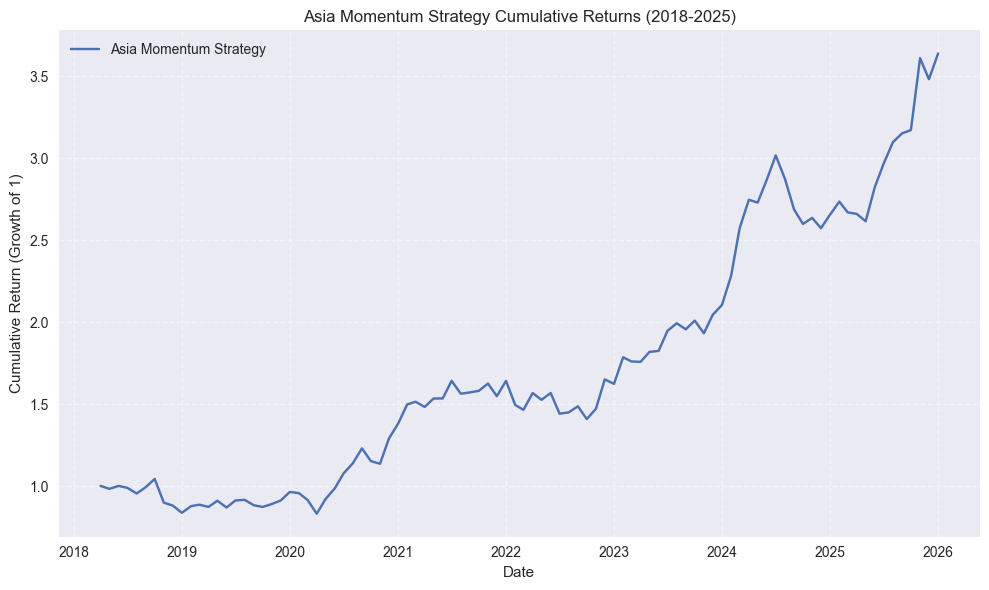

In [6]:
# 6. 결과 시각화 (누적 수익률 그래프)

def plot_cumulative_returns(cum_returns: pd.Series):
    plt.figure(figsize=(10, 6))
    plt.plot(cum_returns.index, cum_returns.values, label="Asia Momentum Strategy")
    plt.title("Asia Momentum Strategy Cumulative Returns (2018-2025)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (Growth of 1)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


cum_returns = (1 + portfolio_returns).cumprod()
plot_cumulative_returns(cum_returns)

compute_performance_metrics

- 누적수익률:3.64x = 264% 수익
- Sharpe ratio: 수익 대비 위험 비율 
- MDD: 고점 대비 최대 얼마나 떨어졌는지 (-20.34%)

In [ ]:
# 7. Sharpe ratio, MDD 계산 및 출력

def compute_performance_metrics(portfolio_returns: pd.Series):
    """Compute cumulative returns, Sharpe ratio (annualized), and MDD."""
    cum_returns = (1 + portfolio_returns).cumprod()

    # Annualized Sharpe ratio (monthly data, risk-free rate = 0)
    mean_ret = portfolio_returns.mean()
    std_ret = portfolio_returns.std()
    sharpe = np.nan
    if std_ret != 0 and not np.isnan(std_ret):
        sharpe = (mean_ret / std_ret) * np.sqrt(12) # 연환산 sharpe ratio
        # 연환산 sharpe ratio = 월별 수익률 평균 / 월별 수익률 표준편차 * 12개월 곱
        # 월별 수익률 표준편차가 작으면 수익률 안정적이고 평균 수익률이 높아야 좋은 포트폴리오

    # Maximum Drawdown(MDD)
    # 누적 수익률이 과거 고점 대비 최대 얼마나 하락했는지
    running_max = cum_returns.cummax()
    drawdowns = cum_returns / running_max - 1.0
    mdd = drawdowns.min()

    return cum_returns, sharpe, mdd


cum_returns, sharpe, mdd = compute_performance_metrics(portfolio_returns)
print("Backtest Results (2018-2025)")
print("-------------------------------------")
print(f"Final cumulative return: {cum_returns.iloc[-1]:.2f}x")
print(f"Annualized Sharpe ratio: {sharpe:.3f}")
print(f"Maximum drawdown (MDD): {mdd:.2%}")

Backtest Results (2018-2025)
-------------------------------------
Final cumulative return: 3.64x
Annualized Sharpe ratio: 0.996
Maximum drawdown (MDD): -20.34%
